In [ ]:
pip install ultralytics opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
import cv2
import time
from ultralytics import YOLO

# Load YOLO models
model_v8 = YOLO('yolov8n.pt')       # or yolov8s.pt, yolov8m.pt etc.
model_v11 = YOLO('yolo11n.pt')     # Provided by Ultralytics (experimental)
model_v12 = YOLO('yolo12n.pt')     # Provided by Ultralytics (experimental)

models = {
    "YOLOv8": model_v8,
    "YOLOv11": model_v11,
    "YOLOv12": model_v12
}

# Load your video (path to your smartphone-recorded video)
video_path = "/content/131232-749706873_small.mp4"
cap = cv2.VideoCapture(video_path)

# Frame processing settings
frame_count = 0
max_frames = 100  # Process only 100 frames for comparison

results = {}

for name, model in models.items():
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # Reset video to first frame
    frame_count = 0
    total_time = 0
    total_detections = 0
    detected_classes = set()

    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        start = time.time()
        detections = model(frame, verbose=False)[0]
        end = time.time()

        total_time += (end - start)

        # Count and collect class names
        for d in detections.boxes.cls:
            class_id = int(d.item())
            class_name = model.names[class_id]
            detected_classes.add(class_name)
            total_detections += 1

        frame_count += 1

    avg_fps = frame_count / total_time
    results[name] = {
        "FPS": round(avg_fps, 2),
        "Total Detections": total_detections,
        "Unique Classes": list(detected_classes)
    }

cap.release()


In [ ]:
print("Model Comparison (100 Frames):\n")
for name, data in results.items():
    print(f"🔹 {name}")
    print(f"   - FPS: {data['FPS']}")
    print(f"   - Total Objects Detected: {data['Total Detections']}")
    print(f"   - Unique Classes Detected: {', '.join(data['Unique Classes'])}\n")


Model Comparison (100 Frames):

🔹 YOLOv8
   - FPS: 4.61
   - Total Objects Detected: 908
   - Unique Classes Detected: person, traffic light, motorcycle, bus, bicycle, car, truck

🔹 YOLOv11
   - FPS: 6.02
   - Total Objects Detected: 1036
   - Unique Classes Detected: person, motorcycle, bus, car, truck

🔹 YOLOv12
   - FPS: 5.63
   - Total Objects Detected: 1072
   - Unique Classes Detected: person, traffic light, motorcycle, bus, car, truck



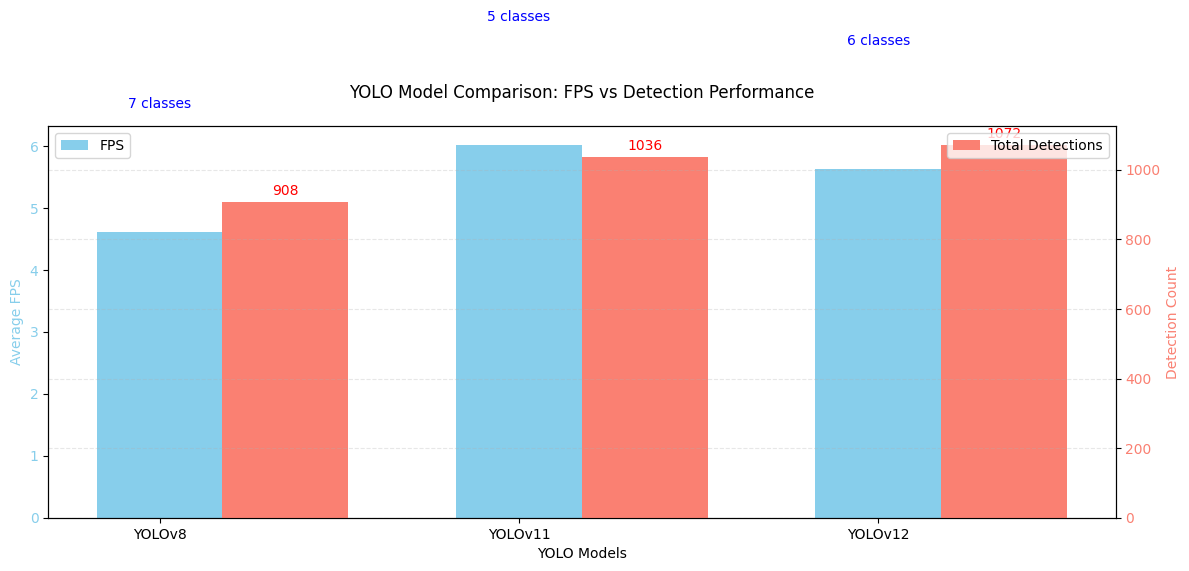

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from your results dictionary
model_names = list(results.keys())
fps_values = [results[name]['FPS'] for name in model_names]
detection_counts = [results[name]['Total Detections'] for name in model_names]
unique_classes = [len(results[name]['Unique Classes']) for name in model_names]

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for FPS
bar_width = 0.35
index = np.arange(len(model_names))
bars1 = ax1.bar(index, fps_values, bar_width, color='skyblue', label='FPS')

ax1.set_xlabel('YOLO Models')
ax1.set_ylabel('Average FPS', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(index)
ax1.set_xticklabels(model_names)

# Create secondary axis for detections
ax2 = ax1.twinx()
bars2 = ax2.bar(index + bar_width, detection_counts, bar_width, color='salmon', label='Total Detections')
ax2.set_ylabel('Detection Count', color='salmon')
ax2.tick_params(axis='y', labelcolor='salmon')

# Add unique classes as text labels
for i, (fps, count, uniq) in enumerate(zip(fps_values, detection_counts, unique_classes)):
    ax1.text(i, fps + 2, f'{uniq} classes', ha='center', color='blue')
    ax2.text(i + bar_width, count + 20, str(count), ha='center', color='red')

# Add title and legends
plt.title('YOLO Model Comparison: FPS vs Detection Performance', pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Add grid and adjust layout
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Save and show plot
plt.savefig('yolo_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

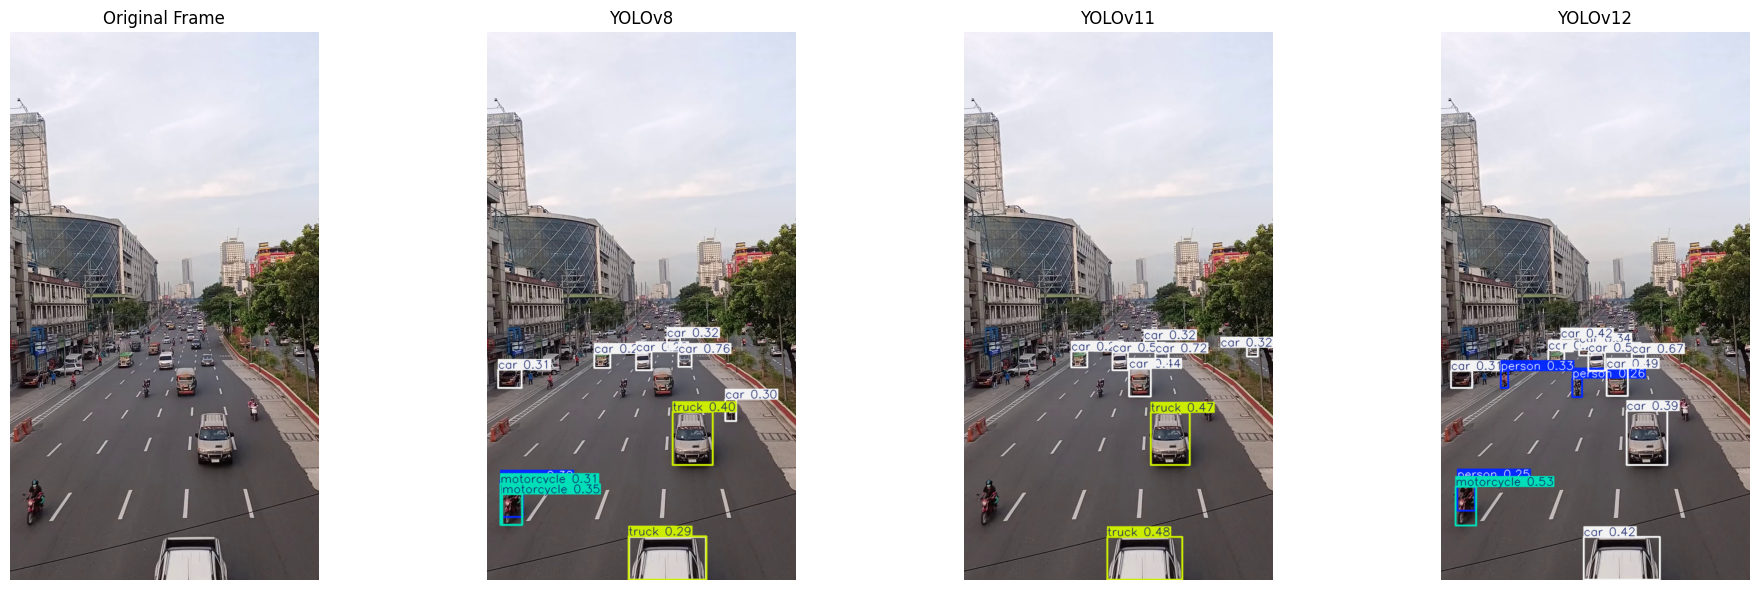

In [ ]:
# 2. Single Frame Comparison
def compare_single_frame(models, video_path):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise ValueError("Could not read frame from video")

    results = {}
    for name, model in models.items():
        results[name] = model(frame, verbose=False)[0].plot()

    # Convert to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results_rgb = {name: cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for name, img in results.items()}

    # Create subplot
    plt.figure(figsize=(20, 6))
    plt.subplot(1, 4, 1)
    plt.imshow(frame_rgb)
    plt.title("Original Frame")
    plt.axis('off')

    for i, (name, img) in enumerate(results_rgb.items(), start=2):
        plt.subplot(1, 4, i)
        plt.imshow(img)
        plt.title(name)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('yolo_frame_comparison.png', dpi=300)
    plt.show()

compare_single_frame(models, video_path)